# Multiple Linear Regression (OLS)

> **Note**: Theoretical documentation available [here](https://ccaudek.github.io/ds4psy_2023/400_reglin_1.html) .

In [12]:
# import libraries
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# User input
FILE_NAME = 'ols-sample.xlsx'
VAR_X = ['esami_sem', 'genere']
VAR_Y = 'livello_stress'


In [14]:
# access data
df = pd.read_excel(f'data/{FILE_NAME}', decimal=',')

df.head()

,id,esami_sem,genere,livello_stress
0,1,5,1,6
1,2,5,1,10
2,3,5,1,10
3,4,5,1,5
4,5,4,0,8


## 1. Dataset EDA

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              30 non-null     int64
 1   esami_sem       30 non-null     int64
 2   genere          30 non-null     int64
 3   livello_stress  30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB


In [16]:
df.describe().round(2)

,id,esami_sem,genere,livello_stress
count,30.00,30.00,30.00,30.00
mean,15.50,4.27,0.70,6.73
std,8.80,0.83,0.47,2.50
min,1.00,3.00,0.00,1.00
25%,8.25,4.00,0.00,5.00
50%,15.50,4.00,1.00,7.50
75%,22.75,5.00,1.00,8.00
max,30.00,6.00,1.00,10.00


## 2. Verifying OLS assumnptions

## 3. Model Fitting

In [17]:

X_INDEX_1 = 0
X_INDEX_2 = 1

formula = f'{VAR_Y} ~ {VAR_X[X_INDEX_1]} * {VAR_X[X_INDEX_2]}'

model = smf.ols(formula, data=df).fit()
print(f'\nModello di Regressione Lineare\n')
print(model.summary())


Modello di Regressione Lineare

                            OLS Regression Results                            
Dep. Variable:         livello_stress   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     5.232
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00585
Time:                        20:55:18   Log-Likelihood:                -62.515
No. Observations:                  30   AIC:                             133.0
Df Residuals:                      26   BIC:                             138.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Interce

## 4. Visualizations

In [18]:
df.head()

,id,esami_sem,genere,livello_stress
0,1,5,1,6
1,2,5,1,10
2,3,5,1,10
3,4,5,1,5
4,5,4,0,8


In [19]:
params = model.params

In [20]:
# x values
ax_x = 'esami_sem'
x = np.linspace(0, df[ax_x].max(), 100)

# coefficients
b0 = model.params['Intercept']
b1 = model.params['esami_sem']
b2 = model.params['genere']
b3 = model.params['esami_sem:genere']

# f lines
y_d_0 = b0 + b1 * x 
y_d_1 = b0 + b1 * x + b2 
y_interaction = b0 + b1 * x + b2 + b3 * x


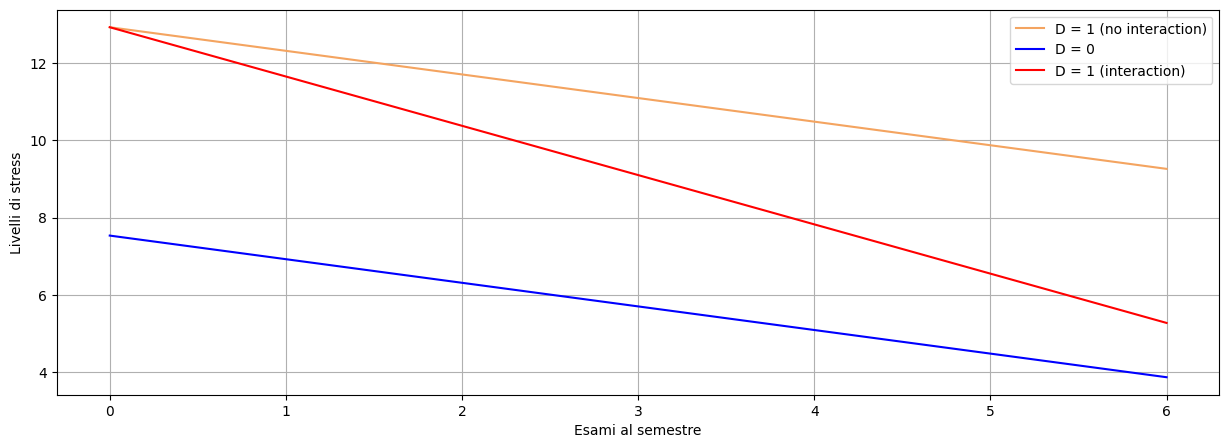

In [30]:
# matplotlib graph

plt.figure(figsize=(15, 5))
plt.plot(x, y_d_1, color='sandybrown', label='D = 1 (no interaction)', )
plt.plot(x, y_d_0, color='blue', label='D = 0')
plt.plot(x, y_interaction, color='red', label='D = 1 (interaction)')
plt.xlabel("Esami al semestre")
plt.ylabel("Livelli di stress")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import plotly.express as px
import plotly.graph_objects as go 

fig = px.scatter(
    df, 
    x='esami_sem', 
    y='livello_stress', 
    hover_data={
        'esami_sem': True,
        'livello_stress': True,
        'genere': True
    }
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_0,
        mode='lines',
        name='D = 0', 
    )
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_1,
        mode='lines',
        line=dict(dash='dash'),
        name='D = 1 (no interaction)'
    )
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_interaction,
        mode='lines',
        name='D = 1 (interaction)'
    )
)

fig.update_layout(
    title='OLS with dummy variable and interaction',
    xaxis_title='Exams per semester',
    yaxis_title='Stress levels',
    template='simple_white'
)

fig.show()